# 📝 Notebook 3: Lyrics Preprocessing
## Building a Vocabulary and Tokenization Pipeline From Scratch

---

> **Notebook 3 of 9** | Prerequisites: Notebook 1 complete, `subset_50.csv` exists.

---

### What This Notebook Builds

```
Raw lyrics text
    → Clean (unicode, HTML, punctuation)
    → Tokenize (whitespace split)
    → Build Vocabulary (freq-filtered, special tokens)
    → Token IDs (integer sequences)
    → Pad/Truncate to fixed length L=256
    → Attention masks
    → Save .npy
```

**No HuggingFace. No external tokenizers. Everything built manually.**

**Output per song:**
- `token_ids`: shape `(256,)` — integer token IDs
- `attention_mask`: shape `(256,)` — 1 for real tokens, 0 for padding

### Special Tokens Used

| Token | ID | Purpose |
|-------|----|---------|
| `[PAD]` | 0 | Padding to fixed length |
| `[UNK]` | 1 | Unknown words (OOV) |
| `[CLS]` | 2 | Classification token (start of sequence) |
| `[SEP]` | 3 | Separator (end of sequence) |
| `[NO_LYRICS]` | 4 | Entire sequence is empty/missing |

---
## 📐 Mathematical Background

### 3.1 — Token Embeddings

A vocabulary of size `V` maps each token to a learnable vector in ℝᵈ:

$$\text{Embedding}(id) = E[id, :] \in \mathbb{R}^d$$

The embedding matrix `E ∈ ℝ^{V×d}` is initialized randomly and learned during training.

### 3.2 — Positional Encoding

Transformers have no notion of order by default. Positional encoding adds position information:

$$\text{PE}(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$
$$\text{PE}(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

The input to the transformer is: `token_embedding + positional_encoding`

### 3.3 — Attention Masks

Padding tokens should not attend to other tokens (and should not be attended to).
The attention mask is a binary tensor:

$$\text{mask}[i] = \begin{cases} 1 & \text{if token } i \text{ is real} \\ 0 & \text{if token } i \text{ is padding} \end{cases}$$

In the attention computation, padding positions are masked by setting their scores to `-∞` before softmax, which makes their attention weights effectively 0.

### 3.4 — Why Fixed-Length Sequences?

GPU matrix operations require fixed-size tensors. All sequences in a batch must have the same length `L`. We achieve this by:
- **Truncating** sequences longer than `L` (keep first L tokens)
- **Padding** sequences shorter than `L` (append `[PAD]` tokens)

We choose `L=256` because:
- Average pop song lyrics: ~200–400 words
- 256 is a power of 2 (GPU-friendly)
- Attention complexity: O(256²) = 65,536 operations — tractable on 8GB GPU

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 3.1 — IMPORTS AND CONFIG
# ─────────────────────────────────────────────────────────────

import re
import json
import unicodedata
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm

# ── Paths ─────────────────────────────────────────────────────
BASE_DIR = Path("../")
LYRICS_DIR   = BASE_DIR /'data'/ 'raw' / 'lyrics'
SUBSET_CSV   = BASE_DIR / 'subsets' / 'subset_50.csv'
PROC_LYRICS  = BASE_DIR / 'data'/ 'processed' / 'lyric_tokens'
FIGURES_DIR  = BASE_DIR / 'figures' / 'lyrics'
VOCAB_PATH   = BASE_DIR /'data'/ 'processed' / 'vocabulary.json'

PROC_LYRICS.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Tokenization Hyperparameters ──────────────────────────────
MAX_SEQ_LEN    = 256    # Fixed sequence length (L)
MIN_WORD_FREQ  = 5      # Include words appearing >= this many times
                        # With only 50 songs, keep all words (freq >= 1)
                        # Scale to 2–3 for 500+ songs
MAX_VOCAB_SIZE = 50000   # Hard cap on vocabulary size

# ── Special Token Definitions ────────────────────────────────
SPECIAL_TOKENS = {
    '[PAD]':      0,
    '[UNK]':      1,
    '[CLS]':      2,
    '[SEP]':      3,
    '[NO_LYRICS]': 4,
}

print("=" * 50)
print("LYRICS PREPROCESSING CONFIG")
print("=" * 50)
print(f"Max sequence length : {MAX_SEQ_LEN}")
print(f"Min word frequency  : {MIN_WORD_FREQ}")
print(f"Max vocab size      : {MAX_VOCAB_SIZE}")
print(f"Special tokens      : {SPECIAL_TOKENS}")
print()
print(f"Output per song:")
print(f"  token_ids      : ({MAX_SEQ_LEN},) int64")
print(f"  attention_mask : ({MAX_SEQ_LEN},) int64")

LYRICS PREPROCESSING CONFIG
Max sequence length : 256
Min word frequency  : 5
Max vocab size      : 50000
Special tokens      : {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[NO_LYRICS]': 4}

Output per song:
  token_ids      : (256,) int64
  attention_mask : (256,) int64


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 3.2 — TEXT CLEANING PIPELINE (FROM SCRATCH)
# ─────────────────────────────────────────────────────────────
# Every regex is explained. No black-box cleaning.

def clean_lyrics(text: str) -> str:
    """
    Normalize raw lyrics text to clean lowercase tokens.
    
    Processing order matters:
    1. Handle None/empty → return empty string
    2. HTML entity decoding (& → &, &nbsp; → space)
    3. Unicode normalization (ñ → n, é → e for simplicity)
    4. Remove HTML tags (<i>, <br>, etc.)
    5. Remove structural markers ([Verse 1], [Chorus])
    6. Remove parenthetical annotations (*(crowd noise)*)
    7. Lowercase
    8. Expand contractions (don't → do not) — improves vocab coverage
    9. Remove punctuation except apostrophes (keep it's → its)
    10. Remove standalone apostrophes
    11. Normalize whitespace → single space
    12. Strip
    """
    if not text or not isinstance(text, str):
        return ''
    
    # Step 2: HTML entities
    text = html.unescape(text)
    
    # Step 3: Unicode normalization (NFKD decomposes characters)
    text = unicodedata.normalize('NFKD', text)
    # Remove non-ASCII accents (e → e, ñ → n)
    text = text.encode('ascii', errors='ignore').decode('ascii')
    
    # Step 4: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Step 5: Remove structural song markers [Verse 1], [Chorus], [Bridge], etc.
    text = re.sub(r'\[[^\]]*\]', ' ', text)
    
    # Step 6: Remove parenthetical annotations
    text = re.sub(r'\([^)]*\)', ' ', text)
    
    # Step 7: Lowercase
    text = text.lower()
    
    # Step 8: Common contractions → expanded (improves semantic coverage)
    contractions = {
        "don't": "do not", "won't": "will not", "can't": "cannot",
        "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
        "you're": "you are", "you've": "you have", "you'll": "you will",
        "it's": "it is", "that's": "that is", "there's": "there is",
        "they're": "they are", "we're": "we are", "wasn't": "was not",
        "isn't": "is not", "aren't": "are not", "couldn't": "could not",
        "wouldn't": "would not", "shouldn't": "should not",
        "he's": "he is", "she's": "she is", "let's": "let us",
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    
    # Step 9: Remove punctuation (keep letters, digits, spaces)
    text = re.sub(r"[^a-z0-9\s]", ' ', text)
    
    # Step 10: Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# ── Test on diverse examples ──────────────────────────────────
test_cases = [
    ("[Chorus]\nI don't wanna &amp; you can't stop me!", "normal lyrics with HTML"),
    ("<i>Forever</i> (Studio Version) [Verse 2]\nWe're okay",  "HTML tags + markers"),
    ("Nada más\nÉté\nMañana", "accented characters"),
    ("", "empty string"),
    (None, "None value"),
]

print("Text Cleaning Tests:")
print("=" * 60)
for raw, desc in test_cases:
    cleaned = clean_lyrics(raw)
    print(f"[{desc}]")
    print(f"  IN : {repr(raw)}")
    print(f"  OUT: {repr(cleaned)}")
    print()

Text Cleaning Tests:
[normal lyrics with HTML]
  IN : "[Chorus]\nI don't wanna &amp; you can't stop me!"
  OUT: 'i do not wanna you cannot stop me'

[HTML tags + markers]
  IN : "<i>Forever</i> (Studio Version) [Verse 2]\nWe're okay"
  OUT: 'forever we are okay'

[accented characters]
  IN : 'Nada más\nÉté\nMañana'
  OUT: 'nada mas ete manana'

[empty string]
  IN : ''
  OUT: ''

[None value]
  IN : None
  OUT: ''



In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3.3 — LOAD ALL LYRICS AND CLEAN
# ─────────────────────────────────────────────────────────────

assert SUBSET_CSV.exists(), f"❌ {SUBSET_CSV} not found. Run Notebook 1 first."
df = pd.read_csv(SUBSET_CSV)
print(f"✅ Loaded {len(df)} songs from subset.")

def load_lyrics_for_song(row):
    """
    Load raw lyrics text from either:
    1. A dedicated column in the CSV (lyrics_path or raw_lyrics)
    2. A .txt file in LYRICS_DIR/{id}.txt
    Returns (raw_text, source_description)
    """
    id = str(row['id'])
    
    # Check if lyrics are in a CSV column
    for col in ['lyrics', 'raw_lyrics', 'text']:
        if col in row.index and isinstance(row[col], str) and len(row[col].strip()) > 5:
            return row[col], f'csv_column:{col}'
    
    # Check if there's a separate lyrics file
    for ext in ['.txt', '.lrc']:
        lyric_file = LYRICS_DIR / f"{id}{ext}"
        if lyric_file.exists():
            with open(lyric_file, 'r', encoding='utf-8', errors='replace') as f:
                return f.read(), f'file:{lyric_file.name}'
    
    # Missing lyrics — will become [NO_LYRICS] token
    return '', 'MISSING'


# Load and clean all lyrics
lyrics_records = []
all_cleaned_texts = []

for _, row in df.iterrows():
    raw_text, source = load_lyrics_for_song(row)
    cleaned = clean_lyrics(raw_text)
    tokens_rough = cleaned.split() if cleaned else []
    
    is_missing = (source == 'MISSING' or len(cleaned.strip()) == 0)
    
    lyrics_records.append({
        'id':       str(row['id']),
        'genre':         row.get('genre', '?'),
        'raw_text':      raw_text[:200] if raw_text else '',
        'cleaned_text':  cleaned,
        'n_raw_chars':   len(raw_text) if raw_text else 0,
        'n_tokens':      len(tokens_rough),
        'is_missing':    is_missing,
        'source':        source,
    })
    if not is_missing:
        all_cleaned_texts.append(cleaned)

df_lyrics = pd.DataFrame(lyrics_records)
print()
print(f"Lyrics stats:")
print(f"  Total songs      : {len(df_lyrics)}")
print(f"  With lyrics      : {(~df_lyrics['is_missing']).sum()}")
print(f"  Missing lyrics   : {df_lyrics['is_missing'].sum()}  ← will use [NO_LYRICS] token")
print(f"  Mean token count : {df_lyrics['n_tokens'].mean():.0f} words")
print(f"  Max token count  : {df_lyrics['n_tokens'].max()}")
print(f"  Min (non-zero)   : {df_lyrics[df_lyrics['n_tokens']>0]['n_tokens'].min()}")
print()
display(df_lyrics[['id','genre','n_tokens','is_missing','source']].head(8))

✅ Loaded 10000 songs from subset.

Lyrics stats:
  Total songs      : 10000
  With lyrics      : 9959
  Missing lyrics   : 41  ← will use [NO_LYRICS] token
  Mean token count : 220 words
  Max token count  : 1232
  Min (non-zero)   : 1



,id,genre,n_tokens,is_missing,source
0,lUJHN9keOtaNGCYK,"latin,rock,psychedelic rock",205,False,file:lUJHN9keOtaNGCYK.txt
1,3MEb9LZbB80nQ1a8,"jazz,blues",92,False,file:3MEb9LZbB80nQ1a8.txt
2,RbaDhF3EoczkLKJl,"jazz,blues,vocal jazz",191,False,file:RbaDhF3EoczkLKJl.txt
3,jfzhRuGuLSLd2IIx,"blues,delta blues",200,False,file:jfzhRuGuLSLd2IIx.txt
4,bQIxtIWyMf9nxWED,"blues,delta blues",231,False,file:bQIxtIWyMf9nxWED.txt
5,ScfSrFBa4lrCZDko,"jazz,easy listening,swing",115,False,file:ScfSrFBa4lrCZDko.txt
6,xio2irTmQljX6ipz,"jazz,bebop,jazz piano",1,False,file:xio2irTmQljX6ipz.txt
7,mm2nhlo9eEObGGfC,"jazz,easy listening,swing,lounge",166,False,file:mm2nhlo9eEObGGfC.txt


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 3.4 — BUILD VOCABULARY FROM SCRATCH
# ─────────────────────────────────────────────────────────────
# Vocabulary = mapping from word string → integer ID
# Built from all words appearing in the training set.

print("Building vocabulary from scratch...")
print()

# Count all word frequencies across all songs
word_counts = Counter()
for text in all_cleaned_texts:
    words = text.split()
    word_counts.update(words)

print(f"Total unique words (raw)  : {len(word_counts)}")
print(f"Top 20 most common words  :")
for word, count in word_counts.most_common(20):
    print(f"  {word:<20} : {count}")
print()

# Filter by minimum frequency
filtered_words = [
    (w, c) for w, c in word_counts.most_common()
    if c >= MIN_WORD_FREQ
]
print(f"Words with freq >= {MIN_WORD_FREQ}: {len(filtered_words)}")

# Cap at MAX_VOCAB_SIZE (take most frequent)
filtered_words = filtered_words[:MAX_VOCAB_SIZE - len(SPECIAL_TOKENS)]
print(f"After MAX_VOCAB_SIZE cap  : {len(filtered_words)} words")

# Build token → ID mapping
# Special tokens get the lowest IDs (0–4)
token_to_id = dict(SPECIAL_TOKENS)  # {'[PAD]': 0, '[UNK]': 1, ...}
next_id = len(SPECIAL_TOKENS)       # Start regular word IDs at 5

for word, count in filtered_words:
    if word not in token_to_id:
        token_to_id[word] = next_id
        next_id += 1

# Reverse mapping: ID → token
id_to_token = {v: k for k, v in token_to_id.items()}

VOCAB_SIZE = len(token_to_id)
print()
print(f"Final vocabulary size: {VOCAB_SIZE}")
print(f"  Special tokens    : {len(SPECIAL_TOKENS)}")
print(f"  Regular words     : {VOCAB_SIZE - len(SPECIAL_TOKENS)}")
print()
print("Sample ID assignments:")
for word, wid in list(token_to_id.items())[:10]:
    print(f"  ID {wid:4d} → '{word}'")

# Save vocabulary
vocab_data = {
    'token_to_id': token_to_id,
    'id_to_token': {str(k): v for k, v in id_to_token.items()},
    'vocab_size': VOCAB_SIZE,
    'special_tokens': SPECIAL_TOKENS,
    'max_seq_len': MAX_SEQ_LEN,
    'min_word_freq': MIN_WORD_FREQ,
}
VOCAB_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(VOCAB_PATH, 'w') as f:
    json.dump(vocab_data, f, indent=2)

print(f"\n✅ Vocabulary saved to: {VOCAB_PATH}")

Building vocabulary from scratch...

Total unique words (raw)  : 53228
Top 20 most common words  :
  i                    : 97006
  you                  : 76251
  the                  : 70668
  to                   : 41072
  a                    : 38827
  and                  : 38827
  it                   : 35759
  me                   : 35449
  is                   : 32361
  my                   : 25827
  in                   : 24702
  not                  : 23853
  do                   : 21526
  am                   : 20544
  of                   : 19768
  that                 : 19208
  your                 : 18543
  we                   : 18231
  are                  : 17744
  on                   : 16504

Words with freq >= 5: 15104
After MAX_VOCAB_SIZE cap  : 15104 words

Final vocabulary size: 15109
  Special tokens    : 5
  Regular words     : 15104

Sample ID assignments:
  ID    0 → '[PAD]'
  ID    1 → '[UNK]'
  ID    2 → '[CLS]'
  ID    3 → '[SEP]'
  ID    4 → '[NO_LYRICS]'


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3.5 — TOKENIZATION FUNCTION (FROM SCRATCH)
# ─────────────────────────────────────────────────────────────

PAD_ID       = SPECIAL_TOKENS['[PAD]']
UNK_ID       = SPECIAL_TOKENS['[UNK]']
CLS_ID       = SPECIAL_TOKENS['[CLS]']
SEP_ID       = SPECIAL_TOKENS['[SEP]']
NO_LYRICS_ID = SPECIAL_TOKENS['[NO_LYRICS]']

def tokenize(cleaned_text: str,
             token_to_id: dict,
             max_len: int = MAX_SEQ_LEN) -> tuple:
    """
    Convert cleaned text to padded token IDs + attention mask.
    
    Sequence structure:
        [CLS] word1 word2 ... wordN [SEP] [PAD] [PAD] ...
        └─── up to max_len total tokens ───────────────────┘
    
    For missing lyrics:
        [NO_LYRICS] [PAD] [PAD] ... [PAD]
    
    Returns:
        token_ids      : np.ndarray shape (max_len,) int64
        attention_mask : np.ndarray shape (max_len,) int64
                         1 for real tokens (including [CLS], [SEP])
                         0 for [PAD] tokens
    """
    token_ids = np.zeros(max_len, dtype=np.int64)
    attn_mask = np.zeros(max_len, dtype=np.int64)
    
    # Missing lyrics: special representation
    if not cleaned_text or not cleaned_text.strip():
        token_ids[0] = NO_LYRICS_ID
        attn_mask[0] = 1
        return token_ids, attn_mask
    
    words = cleaned_text.split()
    
    # Reserve slots for [CLS] and [SEP]
    max_content = max_len - 2  # slots for actual words
    words = words[:max_content]  # truncate if needed
    
    # Convert words to IDs (unknown words → [UNK])
    ids = [CLS_ID]
    for w in words:
        ids.append(token_to_id.get(w, UNK_ID))
    ids.append(SEP_ID)
    
    # Fill arrays
    n = len(ids)
    token_ids[:n] = ids
    attn_mask[:n] = 1  # Real tokens (including [CLS], [SEP])
    # Positions [n:] remain 0 (PAD_ID, mask=0)
    
    return token_ids, attn_mask


# ── Test tokenization on example ─────────────────────────────
test_song = df_lyrics[~df_lyrics['is_missing']].iloc[0]
test_text = test_song['cleaned_text']

ids, mask = tokenize(test_text, token_to_id)

print("Tokenization Example:")
print("-" * 55)
print(f"Input (first 100 chars): '{test_text[:100]}...'")
print()
print(f"token_ids shape     : {ids.shape}  dtype: {ids.dtype}")
print(f"attention_mask shape: {mask.shape}  dtype: {mask.dtype}")
print()
print(f"First 20 token IDs  : {ids[:20].tolist()}")
print(f"First 20 token strs : {[id_to_token.get(i, '[?]') for i in ids[:20]]}")
print(f"First 20 mask values: {mask[:20].tolist()}")
print()
n_real   = mask.sum()
n_pad    = MAX_SEQ_LEN - n_real
oov_mask = (ids[:n_real] == UNK_ID)
oov_rate = oov_mask.sum() / max(n_real - 2, 1)  # exclude [CLS], [SEP]
print(f"Real tokens (incl. [CLS],[SEP]): {n_real}")
print(f"Padding tokens                 : {n_pad}")
print(f"OOV ([UNK]) rate               : {oov_rate:.2%}")

# Reconstruction sanity check
reconstructed = ' '.join(
    id_to_token.get(i, '[?]')
    for i in ids[:n_real]
    if i not in (PAD_ID, CLS_ID, SEP_ID)
)
print()
print(f"Reconstructed (first 100 chars): '{reconstructed[:100]}'")
print()
print("✅ Tokenization verified.")

Tokenization Example:
-------------------------------------------------------
Input (first 100 chars): 'como en las noches de verano que salia a matar como esas noches de verano llenas de felicidad yo me ...'

token_ids shape     : (256,)  dtype: int64
attention_mask shape: (256,)  dtype: int64

First 20 token IDs  : [2, 296, 181, 589, 2694, 64, 5092, 43, 1, 9, 4938, 296, 4799, 2694, 64, 5092, 1, 64, 5925, 240]
First 20 token strs : ['[CLS]', 'como', 'en', 'las', 'noches', 'de', 'verano', 'que', '[UNK]', 'a', 'matar', 'como', 'esas', 'noches', 'de', 'verano', '[UNK]', 'de', 'felicidad', 'yo']
First 20 mask values: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Real tokens (incl. [CLS],[SEP]): 207
Padding tokens                 : 49
OOV ([UNK]) rate               : 4.88%

Reconstructed (first 100 chars): 'como en las noches de verano que [UNK] a matar como esas noches de verano [UNK] de felicidad yo me s'

✅ Tokenization verified.


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 3.6 — MISSING LYRICS HANDLING
# ─────────────────────────────────────────────────────────────

# Songs with missing lyrics should NOT be silently dropped.
# Instead, they receive a [NO_LYRICS] token at position 0
# and attention_mask = [1, 0, 0, ..., 0]
# The Lyrics Transformer will still output an embedding,
# but the Gated Fusion layer will learn to down-weight it.

test_missing_ids, test_missing_mask = tokenize('', token_to_id)

print("Missing Lyrics Handling:")
print("-" * 40)
print(f"  token_ids[0]     : {test_missing_ids[0]} → '{id_to_token[test_missing_ids[0]]}'")
print(f"  token_ids[1:5]   : {test_missing_ids[1:5].tolist()}  (all [PAD])")
print(f"  attention_mask   : [{test_missing_mask[0]}, {test_missing_mask[1]}, ..., {test_missing_mask[-1]}]")
print(f"  n_real tokens    : {test_missing_mask.sum()}  (only [NO_LYRICS])")
print()
print("Why this approach?")
print("  Purely instrumental songs still have audio + image modalities.")
print("  The [NO_LYRICS] embedding will learn to represent absence of lyrics.")
print("  The Gated Fusion layer will assign near-zero weight to this embedding.")
print("  This is better than skipping such songs entirely.")

Missing Lyrics Handling:
----------------------------------------
  token_ids[0]     : 4 → '[NO_LYRICS]'
  token_ids[1:5]   : [0, 0, 0, 0]  (all [PAD])
  attention_mask   : [1, 0, ..., 0]
  n_real tokens    : 1  (only [NO_LYRICS])

Why this approach?
  Purely instrumental songs still have audio + image modalities.
  The [NO_LYRICS] embedding will learn to represent absence of lyrics.
  The Gated Fusion layer will assign near-zero weight to this embedding.
  This is better than skipping such songs entirely.


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 3.7 — BATCH TOKENIZE ALL 50 SONGS AND SAVE
# ─────────────────────────────────────────────────────────────

print("Tokenizing all songs...")

N_SONGS = len(df_lyrics)

out_ids = np.lib.format.open_memmap(
    PROC_LYRICS / 'token_ids_all.npy',
    mode='w+',
    dtype='int64',
    shape=(N_SONGS, MAX_SEQ_LEN)
)

out_masks = np.lib.format.open_memmap(
    PROC_LYRICS / 'attn_mask_all.npy',
    mode='w+',
    dtype='int64',
    shape=(N_SONGS, MAX_SEQ_LEN)
)


token_summary = []

for i,(_, row) in enumerate(tqdm(df_lyrics.iterrows(), total=len(df_lyrics), desc="Tokenizing")):
    id = row['id']
    cleaned = row['cleaned_text']
    
    ids, mask = tokenize(cleaned, token_to_id)
    
    # --------------------------------------------------------
    # SAVE DIRECTLY INTO MMAP ARRAYS
    # --------------------------------------------------------

    out_ids[i] = ids
    out_masks[i] = mask
    
    # OOV analysis
    n_real = int(mask.sum())
    oov_count = int((ids[:n_real] == UNK_ID).sum())
    oov_rate  = oov_count / max(n_real - 2, 1)
    
    token_summary.append({
        'id':    id,
        'n_real':     n_real,
        'n_pad':      MAX_SEQ_LEN - n_real,
        'oov_count':  oov_count,
        'oov_rate':   oov_rate,
        'is_missing': row['is_missing'],
    })
# ============================================================
# STEP 3 — Flush mmap arrays to disk
# ============================================================

del out_ids
del out_masks

df_tok = pd.DataFrame(token_summary)
print()
print(f"✅ Saved {len(df_tok)*2} .npy files to {PROC_LYRICS}")
print(f"\nTokenization summary:")
print(f"  Mean real tokens  : {df_tok['n_real'].mean():.0f}")
print(f"  Mean OOV rate     : {df_tok['oov_rate'].mean():.2%}")
print(f"  Songs at max_len  : {(df_tok['n_pad'] == 0).sum()} (truncated)")
print(f"  Missing lyrics    : {df_tok['is_missing'].sum()}")

Tokenizing all songs...


Tokenizing:   0%|          | 0/10000 [00:00<?, ?it/s]


✅ Saved 20000 .npy files to ..\data\processed\lyric_tokens

Tokenization summary:
  Mean real tokens  : 183
  Mean OOV rate     : 3.09%
  Songs at max_len  : 3555 (truncated)
  Missing lyrics    : 41


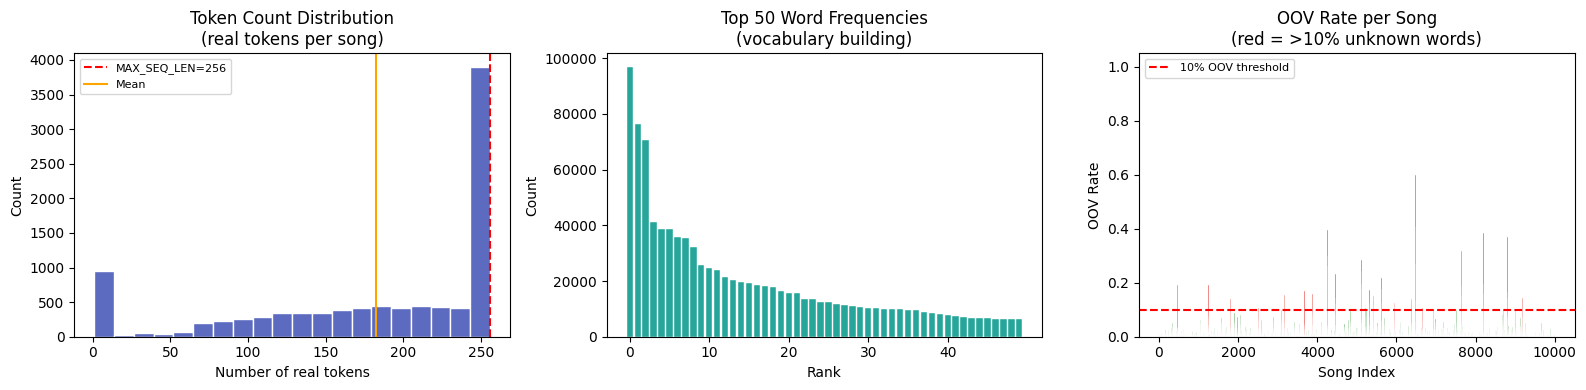

✅ Figures saved.


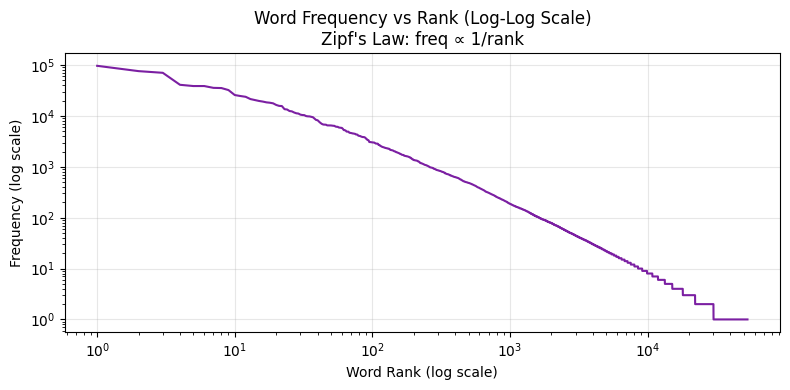


Zipf's Law: Natural language follows a power law.
The top 20% of words cover ~80% of token occurrences.
This justifies vocabulary size caps — rare words add noise, not signal.


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 3.8 — VISUALIZATIONS
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Token length distribution
axes[0].hist(df_tok['n_real'], bins=20, color='#5C6BC0', edgecolor='white')
axes[0].axvline(MAX_SEQ_LEN, color='red', linestyle='--', label=f'MAX_SEQ_LEN={MAX_SEQ_LEN}')
axes[0].axvline(df_tok['n_real'].mean(), color='orange', linestyle='-', label='Mean')
axes[0].set_title('Token Count Distribution\n(real tokens per song)')
axes[0].set_xlabel('Number of real tokens')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# 2. Vocabulary frequency (top 50)
top50 = word_counts.most_common(50)
words50, counts50 = zip(*top50)
axes[1].bar(range(50), counts50, color='#26A69A', edgecolor='white', linewidth=0.3)
axes[1].set_title('Top 50 Word Frequencies\n(vocabulary building)')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(0, 50, 10))

# 3. OOV rate per song
colors_oov = ['#E53935' if r > 0.1 else '#43A047' for r in df_tok['oov_rate']]
axes[2].bar(range(len(df_tok)), df_tok['oov_rate'], color=colors_oov, edgecolor='white', lw=0.3)
axes[2].axhline(0.1, color='red', linestyle='--', label='10% OOV threshold')
axes[2].set_title('OOV Rate per Song\n(red = >10% unknown words)')
axes[2].set_xlabel('Song Index')
axes[2].set_ylabel('OOV Rate')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_lyrics_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figures saved.")

# Vocabulary frequency decay plot (Zipf's Law)
fig2, ax2 = plt.subplots(figsize=(8, 4))
all_freqs = sorted(word_counts.values(), reverse=True)
ax2.loglog(range(1, len(all_freqs)+1), all_freqs, color='#7B1FA2', linewidth=1.5)
ax2.set_title("Word Frequency vs Rank (Log-Log Scale)\nZipf's Law: freq ∝ 1/rank")
ax2.set_xlabel('Word Rank (log scale)')
ax2.set_ylabel('Frequency (log scale)')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_zipf.png', dpi=120)
plt.show()
print("\nZipf's Law: Natural language follows a power law.")
print("The top 20% of words cover ~80% of token occurrences.")
print("This justifies vocabulary size caps — rare words add noise, not signal.")

---
## ✅ Notebook 3 Complete

**What was built:**
- Text cleaning pipeline: HTML, unicode, contractions, punctuation, case
- Vocabulary built from scratch with frequency counting (Zipf's Law explained)
- Special tokens: `[PAD]`, `[UNK]`, `[CLS]`, `[SEP]`, `[NO_LYRICS]`
- Tokenization with padding/truncation → fixed shape `(256,)`
- Attention masks → `(256,)` binary arrays
- Missing lyrics handled gracefully with `[NO_LYRICS]` token
- Saved: `{id}_ids.npy` and `{id}_mask.npy` for all 50 songs
- Vocabulary saved to `vocabulary.json` for reuse in training

**In the Lyrics Transformer:**
```python
# token_ids  : (B, 256)     → Embedding(VOCAB_SIZE, 128) → (B, 256, 128)
# + pos_enc  : (1, 256, 128)
# attn_mask used to zero out padding in attention
# → TransformerEncoder → (B, 256, 128)
# → mean pooling (masked) → (B, 128)  ← lyrics embedding
```

**Next:** Notebook 4 — Image Preprocessing (Vision Transformer pipeline)